# Split hybride par seuils linguistiques et résultats

Ce notebook :
1. **Split le gold test** en deux routes (P1 vs KATE) selon des **seuils** sur la longueur, la densité numérique, les négations et la coverage lexicale (critères issus de `analyse_linguistique_4_cas.ipynb`).
2. Utilise les **prédictions déjà disponibles** (P1 finetuné et KATE few-shot sur tout le gold) pour simuler le résultat hybride : pour chaque exemple, on garde la prédiction du modèle de la route assignée.
3. Affiche les **métriques** (exactitude, macro F1) du système hybride ainsi obtenu.

## 1. Configuration et chargement des données

In [1]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np

# Racine NLI4CT (notebook dans results/hybrid/)
NLI4CT_ROOT = Path.cwd() if (Path.cwd() / "split_gold_test_hybrid.py").exists() else (Path.cwd() / ".." / "..").resolve()

DIR_HYBRID = NLI4CT_ROOT / "results" / "hybrid"
DIR_P1 = NLI4CT_ROOT / "results" / "Prompt 1"
DIR_KATE = NLI4CT_ROOT / "results" / "Fewshot_Kate"

CSV_P1 = DIR_P1 / "pred_ft_qwen7b_NLI4CT_prompt1.csv"
CSV_KATE = DIR_KATE / "pred_fewshot_KATE_qwen7b_NLI4CT_prompt1.csv"

df_p1 = pd.read_csv(CSV_P1)
df_kate = pd.read_csv(CSV_KATE)
print(f"P1: {len(df_p1)} lignes, colonnes: {list(df_p1.columns)}")
print(f"KATE: {len(df_kate)} lignes")
print(f"Indices communs: {sorted(set(df_p1['index']) & set(df_kate['index']))[:5]} ...")

P1: 500 lignes, colonnes: ['index', 'premise', 'hypothesis', 'true_label', 'predicted_label', 'is_correct', 'raw_generated']
KATE: 500 lignes
Indices communs: [0, 1, 2, 3, 4] ...


## 2. Fonctions de features et routage (alignées sur `split_gold_test_hybrid.py` / `analyse_linguistique_4_cas.ipynb`)

In [2]:
def tokenize(text):
    if text is None or not isinstance(text, str):
        return set()
    return set(re.findall(r"[a-zA-Z0-9À-ÿ]+", text.lower()))

def lexical_overlap(premise, hypothesis):
    p, h = tokenize(premise), tokenize(hypothesis)
    if not p and not h:
        return 0.0, 0.0
    inter = len(p & h)
    coverage = inter / len(h) if h else 0.0
    return inter / len(p | h) if (p | h) else 0.0, coverage

NUMERIC_WORDS = frozenset({
    "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten",
    "eleven", "twelve", "thirteen", "fourteen", "fifteen", "sixteen", "seventeen", "eighteen", "nineteen",
    "twenty", "thirty", "forty", "fifty", "sixty", "seventy", "eighty", "ninety",
    "hundred", "thousand", "million", "billion", "first", "second", "third", "fourth", "fifth",
    "sixth", "seventh", "eighth", "ninth", "tenth", "half", "double", "single", "triple", "zero",
})

def numeric_density(text):
    if text is None or not isinstance(text, str):
        return 0, 0, 0, 0
    digits = len(re.findall(r"\d", text))
    pct = len(re.findall(r"\d+%", text))
    units = len(re.findall(r"\d+\s*(?:mg|g|ml|mL|kg|years?|yrs?|months?|days?|weeks?|cycles?|doses?|mg/m²|m²)", text, re.I))
    t_lower = text.lower()
    words_num = sum(1 for w in re.findall(r"\b\w+\b", t_lower) if w in NUMERIC_WORDS)
    return digits, pct, units, words_num

NEGATION_WORDS = frozenset({
    "not", "no", "none", "never", "nothing", "nowhere", "noone", "nobody", "neither", "nor", "cannot",
})

def negation_count(text):
    if text is None or not isinstance(text, str) or not text.strip():
        return 0
    t = text.strip().lower()
    tokens = re.findall(r"\b\w+\b", t)
    return sum(1 for w in tokens if w in NEGATION_WORDS or (len(w) > 2 and w.endswith("n't")))

def word_count(text):
    if text is None or not isinstance(text, str):
        return 0
    return len(re.findall(r"[a-zA-Z0-9À-ÿ]+", text))

def compute_features(premise: str, hypothesis: str) -> dict:
    jaccard, coverage = lexical_overlap(premise, hypothesis)
    digits_p, pct_p, units_p, words_num_p = numeric_density(premise)
    digits_h, pct_h, units_h, words_num_h = numeric_density(hypothesis)
    neg_total = negation_count(premise) + negation_count(hypothesis)
    numeric_total = digits_p + digits_h + units_p + units_h + pct_p + pct_h + words_num_p + words_num_h
    return {
        "lexical_coverage": coverage,
        "numeric_total": numeric_total,
        "neg_total": neg_total,
        "words_premise": word_count(premise),
        "words_hypothesis": word_count(hypothesis),
    }

def route_by_thresholds(features: dict, thresh_numeric: float, thresh_words_premise: float,
                        thresh_neg_total: float, thresh_coverage: float) -> bool:
    """True = route KATE, False = route P1."""
    return (
        features["numeric_total"] >= thresh_numeric
        or features["words_premise"] >= thresh_words_premise
        or features["neg_total"] >= thresh_neg_total
        or features["lexical_coverage"] >= thresh_coverage
    )

## 3. Seuils et assignation des routes

In [3]:
# Seuils par défaut (analyse_linguistique_4_cas : P1✗ KATE✓ vs P1✓ KATE✗)
THRESH_NUMERIC = 53
THRESH_WORDS_PREMISE = 170
THRESH_NEG_TOTAL = 1.2
THRESH_COVERAGE = 0.38

common_idx = sorted(set(df_p1["index"]) & set(df_kate["index"]))
df_common = df_p1[df_p1["index"].isin(common_idx)].sort_values("index").reset_index(drop=True)

features_list = []
routes = []  # "P1" ou "KATE"
for _, row in df_common.iterrows():
    feats = compute_features(row["premise"], row["hypothesis"])
    features_list.append(feats)
    is_kate = route_by_thresholds(feats, THRESH_NUMERIC, THRESH_WORDS_PREMISE, THRESH_NEG_TOTAL, THRESH_COVERAGE)
    routes.append("KATE" if is_kate else "P1")

df_common = df_common.copy()
df_common["route"] = routes
for k in ["lexical_coverage", "numeric_total", "neg_total", "words_premise"]:
    df_common[k] = [f[k] for f in features_list]

n_p1 = (df_common["route"] == "P1").sum()
n_kate = (df_common["route"] == "KATE").sum()
print(f"Route P1: {n_p1}, Route KATE: {n_kate} (total {len(df_common)})")
df_common["route"].value_counts()

Route P1: 182, Route KATE: 318 (total 500)


route
KATE    318
P1      182
Name: count, dtype: int64

## 4. Prédictions hybrides et métriques

In [4]:
pred_p1 = df_p1.set_index("index").loc[common_idx, "predicted_label"].reindex(common_idx).values
pred_kate = df_kate.set_index("index").loc[common_idx, "predicted_label"].reindex(common_idx).values
true_labels = df_common["true_label"].values

hybrid_pred = np.where(np.array(routes) == "KATE", pred_kate, pred_p1)
hybrid_pred = pd.Series(hybrid_pred).str.strip().str.upper().replace({"ENTAILMENT": "Entailment", "CONTRADICTION": "Contradiction", "UNKNOWN": "Unknown"})
true_norm = pd.Series(true_labels).str.strip().str.upper().replace({"ENTAILMENT": "Entailment", "CONTRADICTION": "Contradiction", "UNKNOWN": "Unknown"})

acc = (hybrid_pred.values == true_norm.values).mean()
print(f"Exactitude hybride (split par seuils): {acc:.4f} ({acc*100:.2f}%)")

# Macro F1 binaire (Entailment vs Contradiction), en excluant Unknown
from sklearn.metrics import f1_score
mask = true_norm != "Unknown"
if mask.sum() > 0:
    f1_bin = f1_score(true_norm[mask], hybrid_pred[mask], average="macro", labels=["Entailment", "Contradiction"])
    print(f"Macro F1 (Entailment vs Contradiction, sans Unknown): {f1_bin:.4f}")
else:
    f1_bin = None

Exactitude hybride (split par seuils): 0.7440 (74.40%)
Macro F1 (Entailment vs Contradiction, sans Unknown): 0.7429


## 5. Comparaison P1 seul, KATE seul, Hybride

In [5]:
pred_p1_norm = pd.Series(pred_p1).str.strip().str.upper().replace({"ENTAILMENT": "Entailment", "CONTRADICTION": "Contradiction", "UNKNOWN": "Unknown"})
pred_kate_norm = pd.Series(pred_kate).str.strip().str.upper().replace({"ENTAILMENT": "Entailment", "CONTRADICTION": "Contradiction", "UNKNOWN": "Unknown"})

acc_p1 = (pred_p1_norm.values == true_norm.values).mean()
acc_kate = (pred_kate_norm.values == true_norm.values).mean()
mask = true_norm != "Unknown"
f1_p1 = f1_score(true_norm[mask], pred_p1_norm[mask], average="macro", labels=["Entailment", "Contradiction"]) if mask.sum() else None
f1_kate = f1_score(true_norm[mask], pred_kate_norm[mask], average="macro", labels=["Entailment", "Contradiction"]) if mask.sum() else None

summary = pd.DataFrame({
    "Modèle": ["P1 (finetuné)", "KATE (few-shot)", "Hybride (split par seuils)"],
    "Exactitude": [f"{acc_p1:.2%}", f"{acc_kate:.2%}", f"{acc:.2%}"],
    "Macro F1 (E/C)": [f"{f1_p1:.2%}" if f1_p1 is not None else "-", f"{f1_kate:.2%}" if f1_kate is not None else "-", f"{f1_bin:.2%}" if f1_bin is not None else "-"],
})
summary

,Modèle,Exactitude,Macro F1 (E/C)
0,P1 (finetuné),74.20%,74.72%
1,KATE (few-shot),71.40%,71.24%
2,Hybride (split par seuils),74.40%,74.29%


## 6. Matrice de confusion (hybride)

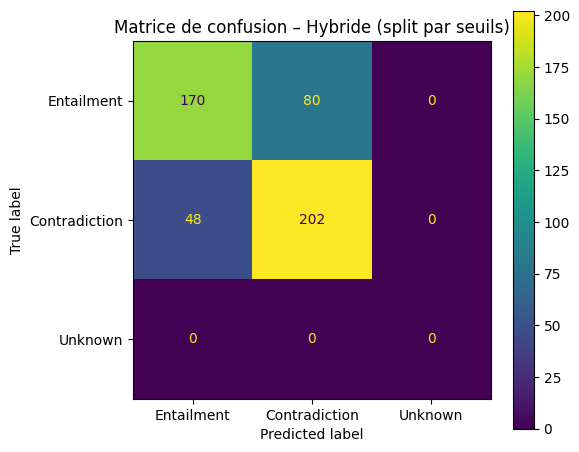

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels_order = ["Entailment", "Contradiction", "Unknown"]
cm = confusion_matrix(true_norm, hybrid_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, values_format="d")
plt.title("Matrice de confusion – Hybride (split par seuils)")
plt.tight_layout()
plt.show()